In [1]:
# ── Cell 1 ·  Core utilities

import os
import time
import warnings
import random
from argparse import Namespace
from pathlib import Path

# Data & Numerical Computing
import numpy as np
import pandas as pd

# Plotting & Visualization
import matplotlib.pyplot as plt

# JAX Framework
import jax
import jax.numpy as jnp
from jax import random as jax_random
from jax import jit
from functools import partial

print('✓ All required libraries imported and configured.')

✓ All required libraries imported and configured.


In [2]:
# ── Cell 2 · Global Configuration & Seeding

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'ggplot')

# Global JAX random key (used across all cells, including main())
JAX_KEY = None

def seed_everything(seed=42):
    """Set global seed for reproducibility across NumPy, Python random, and JAX."""
    global JAX_KEY
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    JAX_KEY = jax_random.PRNGKey(seed)

# Initialize global seed (this JAX_KEY will be used in main() function)
seed_everything(42)

def rk4_step(q, dynamics_fn, dt):
    """Perform a single RK4 integration step.

    Args:
        q: Current state
        dynamics_fn: Function that computes state derivatives
        dt: Time step

    Returns:
        q_new: Updated state after RK4 step
        deriv: Derivative at current state
    """
    k1 = dynamics_fn(q)
    k2 = dynamics_fn(q + 0.5 * dt * k1)
    k3 = dynamics_fn(q + 0.5 * dt * k2)
    k4 = dynamics_fn(q + dt * k3)

    q_new = q + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    deriv = dynamics_fn(q)  # Derivative at current state

    return q_new, deriv

In [3]:
# ── Cell 3 · ROSMA Dataset Directory Resolution

# 1. Safely mount Google Drive ONLY if running in Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass  # Ignores the error if running on Kaggle or locally

# # 2. Define potential paths using modern pathlib syntax (cleaner than os.path.join)
cwd = Path.cwd()
candidates = [
    Path('/content/drive/MyDrive/ROSMA'), # Google Drive path
    cwd / 'ROSMA',                        # Local/Kaggle fallback
    cwd / 'datasets' / 'ROSMA'            # Alternative local fallback
]

# 3. Find the first valid directory using a clean generator expression
ROSMA_ROOT = next((path for path in candidates if path.is_dir()), None)
if ROSMA_ROOT is None:
    raise FileNotFoundError("Could not find ROSMA_ROOT in any candidate paths.")

print(f'ROSMA_ROOT = {ROSMA_ROOT}')

Mounted at /content/drive
ROSMA_ROOT = /content/drive/MyDrive/ROSMA


In [4]:
# ── Cell 4 · ROSMA data-loading utilities — interaction-only ──────────────

from scipy.spatial.transform import Rotation

DT = 1.0 / 50.0  # 50 Hz
H_DATA_GEN = DT
DVRK_FPS = 50  # dVRK kinematics sampling rate
VIDEO_FPS = 15 # Video recording framerate

def load_usable_times(csv_path=None):
    """
    Returns a hardcoded dictionary replacing the dynamic CSV parser.
    Times are pre-converted to integer seconds.
    Keys strictly match the raw IDs from the CSV.
    """
    return {
        'X01_Wire_Chaser_I_01': [(34, 38, 'R')],
        'X01_Wire_Chaser_I_03': [(30, 35, 'R')],
        'X01_Wire_Chaser_I_04': [(17, 26, 'L')],
        'X01_Wire_Chaser_I_06': [(21, 27, 'L')],
        'X02_Wire_Chaser_I_01': [(33, 41, 'R')],
        'X02_Wire_Chaser_I_02': [(23, 35, 'R')],
        'X02_Wire_Chaser_I_03': [(24, 33, 'R')],
        'X02_Wire_Chaser_I_04': [(17, 24, 'L')],
        'X02_Wire_Chaser_I_05': [(14, 26, 'L')],
        'X02_Wire_Chaser_I_06': [(21, 29, 'L')],
        'X03_Wire_Chaser_I_01': [(19, 35, 'R')],
        'X03_Wire_Chaser_I_03': [(22, 27, 'R')],
        'X03_Wire_Chaser_I_04': [(10, 21, 'L')],
        'X03_Wire_Chaser_I_05': [(7, 12, 'L')],
        'X04_Wire_Chaser_I_01': [(37, 54, 'R')],
        'X04_Wire_Chaser_I_02': [(19, 34, 'R')],
        'X04_Wire_Chaser_I_03': [(20, 33, 'L')],
        'X04_Wire_Chaser_I_04': [(17, 36, 'L')],
        'X04_Wire_Chaser_I_05': [(21, 38, 'L')],
        'X04_Wire_Chaser_I_06': [(43, 55, 'L')],
        'X05_Wire_Chaser_I_01': [(49, 70, 'R')],
        'X05_Wire_Chaser_I_02': [(35, 54, 'R')],
        'X05_Wire_Chaser_I_03': [(26, 43, 'R')],
        'X05_Wire_Chaser_I_04': [(33, 50, 'L')],
        'X05_Wire_Chaser_I_05': [(11, 27, 'L')],
        'X05_Wire_Chaser_I_06': [(24, 37, 'L')],
        'X06_Wire_Chaser_I_01': [(24, 36, 'R')],
        'X06_Wire_Chaser_I_02': [(23, 38, 'R')],
        'X06_Wire_Chaser_I_03': [(7, 24, 'R')],
        'X06_Wire_Chaser_I_04': [(12, 28, 'L')],
        'X06_Wire_Chaser_I_05': [(7, 19, 'L')],
        'X06_Wire_Chaser_I_06': [(12, 20, 'L')],
        'X07_Wire_Chaser_I_01': [(11, 25, 'R')],
        'X07_Wire_Chaser_I_02': [(4, 12, 'R')],
        'X07_Wire_Chaser_I_03': [(9, 17, 'R')],
        'X07_Wire_Chaser_I_04': [(14, 23, 'L')],
        'X07_Wire_Chaser_I_05': [(3, 14, 'L')],
        'X07_Wire_Chaser_I_06': [(4, 23, 'L')],
        'X08_Wire_Chaser_I_01': [(25, 42, 'R')],
        'X08_Wire_Chaser_I_02': [(10, 21, 'R')],
        'X08_Wire_Chaser_I_03': [(11, 25, 'R')],
        'X08_Wire_Chaser_I_04': [(9, 25, 'L')],
        'X08_Wire_Chaser_I_05': [(7, 26, 'L')],
        'X08_Wire_Chaser_I_06': [(8, 20, 'L')],
        'X09_Wire_Chaser_I_02': [(14, 30, 'R')],
        'X09_Wire_Chaser_I_03': [(21, 33, 'R')],
        'X09_Wire_Chaser_I_04': [(18, 28, 'L')],
        'X09_Wire_Chaser_I_05': [(7, 17, 'L')],
        'X09_Wire_Chaser_I_06': [(7, 14, 'L')],
        'X10_Wire_Chaser_I_01': [(20, 24, 'R')],
        'X10_Wire_Chaser_I_02': [(2, 8, 'R')],
        'X10_Wire_Chaser_I_03': [(3, 7, 'R')],
        'X10_Wire_Chaser_I_04': [(11, 14, 'L')],
        'X10_Wire_Chaser_I_05': [(7, 24, 'L')],
        'X11_Wire_Chaser_I_01': [(23, 55, 'R')],
        'X11_Wire_Chaser_I_02': [(45, 54, 'R')],
        'X11_Wire_Chaser_I_03': [(23, 35, 'R')],
        'X11_Wire_Chaser_I_04': [(18, 29, 'L')],
        'X11_Wire_Chaser_I_05': [(3, 11, 'L')],
        'X11_Wire_Chaser_I_06': [(9, 15, 'L')],
        'X12_Wire_Chaser_I_01': [(72, 93, 'R')],
        'X12_Wire_Chaser_I_02': [(13, 25, 'R')],
        'X12_Wire_Chaser_I_03': [(43, 61, 'R')],
        'X12_Wire_Chaser_I_04': [(27, 38, 'L')],
        'X12_Wire_Chaser_I_05': [(7, 23, 'L')],
        'X12_Wire_Chaser_I_06': [(10, 20, 'L')]
    }

def load_sync_map():
    """
    Hardcoded (initial_frame, initial_row) pairs from synchronizationData.txt.
    initial_frame is a VIDEO frame index (15 fps); initial_row is the matching
    CSV row (50 Hz). Both are needed to convert elapsed video-file time -> CSV row.
    """
    return {
        'X01_Wire_Chaser_I_01': (11, 34), 'X01_Wire_Chaser_I_02': (7, 8),  'X01_Wire_Chaser_I_03': (11, 24),
        'X01_Wire_Chaser_I_04': (12, 27), 'X01_Wire_Chaser_I_05': (9, 22), 'X01_Wire_Chaser_I_06': (11, 26),
        'X02_Wire_Chaser_I_01': (9, 7),   'X02_Wire_Chaser_I_02': (24, 20), 'X02_Wire_Chaser_I_03': (24, 50),
        'X02_Wire_Chaser_I_04': (14, 9),  'X02_Wire_Chaser_I_05': (18, 24), 'X02_Wire_Chaser_I_06': (27, 49),
        'X03_Wire_Chaser_I_01': (17, 39), 'X03_Wire_Chaser_I_02': (14, 29), 'X03_Wire_Chaser_I_03': (14, 13),
        'X03_Wire_Chaser_I_04': (23, 41), 'X03_Wire_Chaser_I_05': (18, 27),
        'X04_Wire_Chaser_I_01': (39, 46), 'X04_Wire_Chaser_I_02': (20, 47), 'X04_Wire_Chaser_I_03': (16, 19),
        'X04_Wire_Chaser_I_04': (20, 40), 'X04_Wire_Chaser_I_05': (13, 16), 'X04_Wire_Chaser_I_06': (20, 40),
        'X05_Wire_Chaser_I_01': (16, 25), 'X05_Wire_Chaser_I_02': (8, 3),   'X05_Wire_Chaser_I_03': (22, 46),
        'X05_Wire_Chaser_I_04': (11, 11), 'X05_Wire_Chaser_I_05': (22, 30), 'X05_Wire_Chaser_I_06': (22, 47),
        'X06_Wire_Chaser_I_01': (15, 21), 'X06_Wire_Chaser_I_02': (14, 93), 'X06_Wire_Chaser_I_03': (19, 38),
        'X06_Wire_Chaser_I_04': (13, 6),  'X06_Wire_Chaser_I_05': (20, 37), 'X06_Wire_Chaser_I_06': (20, 40),
        'X07_Wire_Chaser_I_01': (21, 51), 'X07_Wire_Chaser_I_02': (16, 43), 'X07_Wire_Chaser_I_03': (19, 50),
        'X07_Wire_Chaser_I_04': (20, 37), 'X07_Wire_Chaser_I_05': (15, 46), 'X07_Wire_Chaser_I_06': (7, 22),
        'X08_Wire_Chaser_I_01': (12, 29), 'X08_Wire_Chaser_I_02': (6, 14),  'X08_Wire_Chaser_I_03': (22, 47),
        'X08_Wire_Chaser_I_04': (19, 51), 'X08_Wire_Chaser_I_05': (16, 47), 'X08_Wire_Chaser_I_06': (16, 45),
        'X09_Wire_Chaser_I_01': (4, 9),   'X09_Wire_Chaser_I_02': (16, 34), 'X09_Wire_Chaser_I_03': (11, 35),
        'X09_Wire_Chaser_I_04': (8, 16),  'X09_Wire_Chaser_I_05': (9, 20),  'X09_Wire_Chaser_I_06': (11, 17),
        'X10_Wire_Chaser_I_01': (7, 11),  'X10_Wire_Chaser_I_02': (3, 4),   'X10_Wire_Chaser_I_03': (12, 18),
        'X10_Wire_Chaser_I_04': (2, 2),   'X10_Wire_Chaser_I_05': (10, 17),
        'X11_Wire_Chaser_I_01': (9, 19),  'X11_Wire_Chaser_I_02': (15, 45), 'X11_Wire_Chaser_I_03': (3, 7),
        'X11_Wire_Chaser_I_04': (14, 36), 'X11_Wire_Chaser_I_05': (10, 27), 'X11_Wire_Chaser_I_06': (12, 36),
        'X12_Wire_Chaser_I_01': (14, 52), 'X12_Wire_Chaser_I_02': (13, 25), 'X12_Wire_Chaser_I_03': (13, 51),
        'X12_Wire_Chaser_I_04': (3, 14),  'X12_Wire_Chaser_I_05': (8, 30),  'X12_Wire_Chaser_I_06': (6, 30)
    }

def _load_rosma_trial_file(path):
    df = pd.read_csv(path)
    df = df[df['Date'].astype(str).str.match(r'^\d{4}-\d{2}-\d{2}')].copy()
    df = df.dropna(subset=['PSM1_orientation_x', 'PSM2_orientation_x'])

    def extract_side(prefix):
        # 1. Standard Kinematics (12-DOF)
        pos = df[[f'{prefix}_position_x', f'{prefix}_position_y', f'{prefix}_position_z']].values
        quat = df[[f'{prefix}_orientation_x', f'{prefix}_orientation_y', f'{prefix}_orientation_z', f'{prefix}_orientation_w']].values
        rotvec = Rotation.from_quat(quat).as_rotvec()
        lin_vel = df[[f'{prefix}_velocity_linear_x', f'{prefix}_velocity_linear_y', f'{prefix}_velocity_linear_z']].values
        ang_vel = df[[f'{prefix}_velocity_angular_x', f'{prefix}_velocity_angular_y', f'{prefix}_velocity_angular_z']].values

        q = np.concatenate([pos, rotvec], axis=-1)
        q_dot = np.concatenate([lin_vel, ang_vel], axis=-1)
        states = jnp.array(np.concatenate([q, q_dot], axis=-1))

        # 2. Ground Truth Wrench Force (3-DOF)
        wrench = df[[f'{prefix}_wrench_force_x', f'{prefix}_wrench_force_y', f'{prefix}_wrench_force_z']].values
        wrench_force = jnp.array(wrench)

        return states, wrench_force

    states_R, wrench_R = extract_side('PSM1')
    states_L, wrench_L = extract_side('PSM2')
    return states_R, wrench_R, states_L, wrench_L

def load_rosma_interaction(data_dir):
    USABLE_TIMES = load_usable_times()
    SYNC_MAP = load_sync_map()
    trials = []

    for file_path in sorted(Path(data_dir).glob('*.csv')):
        name = file_path.stem
        segments = USABLE_TIMES.get(name)
        if not segments:
            continue

        states_R, wrench_R, states_L, wrench_L = _load_rosma_trial_file(file_path)
        num_frames = len(states_R)
        initial_frame, initial_row = SYNC_MAP.get(name, (0, 0))
        t_at_sync = initial_frame / VIDEO_FPS

        for si, (t0, t1, side) in enumerate(segments):
            f0 = max(0, int(round(initial_row + (t0 - t_at_sync) * DVRK_FPS)))
            f1 = min(num_frames - 1, int(round(initial_row + (t1 - t_at_sync) * DVRK_FPS)))

            states = states_R if side == 'R' else states_L
            wrench = wrench_R if side == 'R' else wrench_L

            seg_states = states[f0:f1 + 1]
            seg_wrench = wrench[f0:f1 + 1]

            if len(seg_states) >= 2:
                trials.append({
                    'name': f'{name}_s{si:02d}',
                    'subject': name.split('_')[0],
                    'side': side,
                    'states': seg_states,
                    'wrench': seg_wrench,  # Store wrench data alongside the kinematics
                    'length': len(seg_states),
                    'trial': name,
                    'seg_idx': si
                })
    return trials

def build_transitions(trials):
    """One-step transitions from segmented trials: (x_t, x_{t+1})."""
    xt   = jnp.concatenate([t['states'][:-1] for t in trials], axis=0)  # t -> inputs
    xtp1 = jnp.concatenate([t['states'][1:] for t in trials], axis=0)   # t+1 -> targets
    return xt, xtp1

def build_sequences(trials, K=5):
    """K-step sequences for rollout curriculum."""
    xs, ys = [], []
    for t in trials:
        s = t['states']
        T_ = len(s)
        xs.extend([s[i] for i in range(T_ - K)])                  # Initial states
        ys.extend([s[i + 1 : i + K + 1] for i in range(T_ - K)])  # K-step rollouts
    return jnp.array(xs), jnp.array(ys)

print('✓ ROSMA interaction-only data utilities compiled in JAX (6-DOF).')

✓ ROSMA interaction-only data utilities compiled in JAX (6-DOF).


In [5]:
# ── Cell 5: Generate Data & LOUO Split (ROSMA Adaptation) ──────────────
LOUO_TEST_SUBJECT = 'X04'
DATA_DIR = ROSMA_ROOT  # Map the resolved root to the loader

all_segs = sorted(load_rosma_interaction(DATA_DIR), key=lambda x: x['name'])

# 3. Design Split Strategy (X11 & X12 are Out-Of-Distribution)
OOD_SUBJECTS = {'X11', 'X12'}

id_segs = [s for s in all_segs if s['subject'] not in OOD_SUBJECTS]
ood_segs = [s for s in all_segs if s['subject'] in OOD_SUBJECTS]

# 4. LOUO Split (Train vs ID-Test)
id_subjects = sorted({s['subject'] for s in id_segs})
test_subject = LOUO_TEST_SUBJECT if LOUO_TEST_SUBJECT in id_subjects else (id_subjects[-1] if id_subjects else 'None')

train_segs = [s for s in id_segs if s['subject'] != test_subject]
test_segs  = [s for s in id_segs if s['subject'] == test_subject]

print(f"-> Found {len(train_segs)} Train, {len(test_segs)} Test(ID), and {len(ood_segs)} Test(OOD) segments.")

# 5. Build JAX Arrays
x_tr, y_tr = build_transitions(train_segs)  # Training set
x_nt, y_nt = build_transitions(test_segs)   # In-Distribution Test
x_et, y_et = build_transitions(ood_segs)    # Out-Of-Distribution Test

# 6. Output summary
print('\n✓ ROSMA Data (Interaction-only, JAX Arrays):')
print(f"  Split Subject: '{test_subject}' (LOUO In-Distribution Test)")
print(f"  Train        : {x_tr.shape[0]:>6,} transitions | {x_tr.shape[0]/DVRK_FPS:>6.1f}s")
print(f"  Test (ID)    : {x_nt.shape[0]:>6,} transitions | {x_nt.shape[0]/DVRK_FPS:>6.1f}s")
print(f"  Test (OOD)   : {x_et.shape[0]:>6,} transitions | {x_et.shape[0]/DVRK_FPS:>6.1f}s")

-> Found 48 Train, 6 Test(ID), and 12 Test(OOD) segments.

✓ ROSMA Data (Interaction-only, JAX Arrays):
  Split Subject: 'X04' (LOUO In-Distribution Test)
  Train        : 27,301 transitions |  546.0s
  Test (ID)    :  4,650 transitions |   93.0s
  Test (OOD)   :  8,300 transitions |  166.0s


In [6]:
# ── Cell 6: Dataset comparison: Full vs Interaction-only ───────────────────
from collections import defaultdict
from pathlib import Path

rosma_csv_dir = Path(ROSMA_ROOT)  # Path to raw ROSMA CSV files

full_counts = defaultdict(lambda: {'trials': 0, 'frames': 0})
int_counts  = defaultdict(lambda: {'trials': 0, 'segs': 0, 'frames': 0})

def count_lines(filepath):
    with open(filepath, 'r') as f:
        return max(0, sum(1 for _ in f) - 2)  # Subtract header & trailing NaN footer

for file_path in rosma_csv_dir.glob('*.csv'):
    subj = file_path.stem.split('_')[0]  # Extract subject ID (e.g., 'X01')

    # Categorize trial by data split pool
    split_group = 'OOD' if subj in OOD_SUBJECTS else ('Test' if subj == test_subject else 'Train')

    full_counts[split_group]['trials'] += 1
    full_counts[split_group]['frames'] += count_lines(file_path)

for seg_list, group_name in zip([train_segs, test_segs, ood_segs], ['Train', 'Test', 'OOD']):
    int_counts[group_name]['trials'] = len({s['trial'] for s in seg_list})  # Unique trials
    int_counts[group_name]['segs']   = len(seg_list)                        # Total interaction segments
    int_counts[group_name]['frames'] = sum(s['length'] for s in seg_list)   # Total usable frames

W = 76  # Table width
print('=' * W)
print('  DATASET COMPARISON — Full recording vs Target Interaction only')
print('=' * W)
print(f'  {"Split":<5}  {"───── Full dataset ──────────":29}  {"───── Interaction only ────────────":38}')
print(f'  {"":5}  {"Trials":>6}  {"Frames":>8}  {"Duration":>10}  {"Trials":>6}  {"Segs":>5}  {"Frames":>8}  {"Duration":>10}  {"Kept %":>7}')
print('  ' + '-' * (W - 2))

total_full, total_int = 0, 0
for group in ['Train', 'Test', 'OOD']:
    fc, ic = full_counts[group], int_counts[group]
    pct = 100.0 * ic['frames'] / max(fc['frames'], 1) if fc['frames'] > 0 else 0

    total_full += fc['frames']
    total_int  += ic['frames']

    print(f"  {group:<5}  {fc['trials']:>6}  {fc['frames']:>8,}  {fc['frames']/DVRK_FPS:>9.1f}s  {ic['trials']:>6}  {ic['segs']:>5}  {ic['frames']:>8,}  {ic['frames']/DVRK_FPS:>9.1f}s  {pct:>6.1f}%")

print('  ' + '-' * (W - 2))
pct_tot = 100.0 * total_int / max(total_full, 1)
print(f"  {'ALL':<5}  {'':>6}  {total_full:>8,}  {total_full/DVRK_FPS:>9.1f}s  {'':>6}  {'':>5}  {total_int:>8,}  {total_int/DVRK_FPS:>9.1f}s  {pct_tot:>6.1f}%")
print('=' * W)

if train_segs:  # LOUO Split Stats explicitly guarded against empty arrays
    longest  = max(train_segs, key=lambda t: t['length'])
    shortest = min(train_segs, key=lambda t: t['length'])
    train_subjects = sorted({s['subject'] for s in train_segs})

    print(f'\n── LOUO split (interaction frames) ──')
    print(f'  Train subjects : {train_subjects} → {len(train_segs):2d} segs | {x_tr.shape[0]:>6,} transitions | {x_tr.shape[0]/DVRK_FPS:>6.1f}s')
    print(f'  Test subject   : {test_subject}             → {len(test_segs):2d} segs | {x_nt.shape[0]:>6,} transitions | {x_nt.shape[0]/DVRK_FPS:>6.1f}s')
    print(f'  OOD subjects   : {sorted(list(OOD_SUBJECTS))}             → {len(ood_segs):2d} segs | {x_et.shape[0]:>6,} transitions | {x_et.shape[0]/DVRK_FPS:>6.1f}s')
    print(f'  Longest train seg : {longest["name"]:22s}  {longest["length"]:4d} frames = {longest["length"]/DVRK_FPS:.1f}s')
    print(f'  Shortest train seg: {shortest["name"]:22s}  {shortest["length"]:4d} frames = {shortest["length"]/DVRK_FPS:.1f}s')

  DATASET COMPARISON — Full recording vs Target Interaction only
  Split  ───── Full dataset ──────────  ───── Interaction only ────────────   
         Trials    Frames    Duration  Trials   Segs    Frames    Duration   Kept %
  --------------------------------------------------------------------------
  Train      54    86,163     1723.3s      48     48    27,349      547.0s    31.7%
  Test        6    13,062      261.2s       6      6     4,656       93.1s    35.6%
  OOD        12    26,214      524.3s      12     12     8,312      166.2s    31.7%
  --------------------------------------------------------------------------
  ALL             125,439     2508.8s                   40,317      806.3s    32.1%

── LOUO split (interaction frames) ──
  Train subjects : ['X01', 'X02', 'X03', 'X05', 'X06', 'X07', 'X08', 'X09', 'X10'] → 48 segs | 27,301 transitions |  546.0s
  Test subject   : X04             →  6 segs |  4,650 transitions |   93.0s
  OOD subjects   : ['X11', 'X12']          

In [7]:
# ── Cell 7 ───────────────────────────────────────────────────────────────────
import jax
import jax.numpy as jnp
import flax.linen as nn

class LSTMPredictor(nn.Module):
    """
    Seq-to-next-state LSTM for JIGSAWS kinematics in JAX/Flax.

    Input  : s_t  (B, 12) - normalised [q(6), q_dot(6)]
    Output : s_{t+1}_pred (B, 12) - normalised predicted next state
    """
    hidden_size: int = 256
    num_layers: int = 2
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, x, carry=None, deterministic: bool = True):
        # x: (B, 12) single-step state
        batch_size = x.shape[0]

        # Initialize default zero carry if none provided
        if carry is None:
            # FIX: initialize_carry only takes (rng, batch_dims)
            carry = [nn.LSTMCell(features=self.hidden_size).initialize_carry(
                        jax.random.PRNGKey(0), (batch_size,))
                     for _ in range(self.num_layers)]

        new_carry = []
        hidden_out = x

        # Chain LSTM cells with dropout
        for i in range(self.num_layers):
            c, h = carry[i]
            (new_c, new_h), hidden_out = nn.LSTMCell(features=self.hidden_size)( (c, h), hidden_out )
            new_carry.append((new_c, new_h))

            # Match PyTorch LSTM dropout: applied to the output of each LSTM layer except the last
            if i < self.num_layers - 1:
                hidden_out = nn.Dropout(rate=self.dropout_rate, deterministic=deterministic)(hidden_out)

        # Residual MLP Head: 256 → 128 → 64 → 12
        delta = nn.Dense(128)(hidden_out)
        delta = nn.gelu(delta)
        delta = nn.Dense(64)(delta)
        delta = nn.gelu(delta)
        delta = nn.Dense(x.shape[-1])(delta)

        return x + delta, new_carry

print("✓ LSTM Architecture defined in JAX/Flax.")

✓ LSTM Architecture defined in JAX/Flax.


In [8]:
# ── Cell 8 ───────────────────────────────────────────────────────────────────
import optax
import time
import numpy as np
from argparse import Namespace
from functools import partial
import flax.traverse_util as traverse_util

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ──  Loss & Optimization (JAX) ──────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def loss_fn(params, model, xb, yb, delta_scale, l2_coef, l1_coef, dropout_key):
    """
    Computes the single-step (K=1) loss for the LSTM model.
    """
    # 1. Forward pass (Flax apply requires rngs for dropout)
    # Using carry=None automatically initializes zeros inside the model definition
    preds, _ = model.apply(params, xb, deterministic=False, rngs={'dropout': dropout_key})

    # 2. MSE (Normalized)
    errors = ((preds - yb) / delta_scale)**2
    base_loss = jnp.mean(errors)

    # 3. Global L2 Regularization
    l2_reg = sum(jnp.sum(p**2) for p in jax.tree_util.tree_leaves(params))

    # 4. Targeted L1 Regularization (Applies ONLY if a force_combiner layer exists - safely 0 for LSTM)
    flat_params = traverse_util.flatten_dict(params, sep='/')
    l1_reg = 0.0
    for path, weight in flat_params.items():
        if 'force_combiner' in path and 'kernel' in path:
            l1_reg += jnp.sum(jnp.abs(weight))

    # 5. Final optimization target
    total_loss = base_loss + (l2_coef * l2_reg) + (l1_coef * l1_reg)

    # Return as an array of shape (1,) so the logging print string `sys_losses` still works
    return total_loss, jnp.array([base_loss])

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── JIT Compiled Update Step ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

@partial(jax.jit, static_argnames=['model', 'tx'])
def update_step(model, tx, params, opt_state, xb, yb, delta_scale, l2_coef, l1_coef, dropout_key):
    """Calculates gradients, updates optimizer, and returns new params in a pure function."""
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)

    # Pass the keys to the gradient function
    (total_loss, system_losses), grads = grad_fn(
        params, model, xb, yb, delta_scale, l2_coef, l1_coef, dropout_key
    )

    # Optimizer step
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    return params, opt_state, total_loss, system_losses

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── Training Loop ────────────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def train_loop(model, tx, params, opt_state, iter_count, Xs, Ys, delta_scale, key, training_start, batch_size):
    max_idx = len(Xs) - 1
    key, subkey = jax.random.split(key)
    start_idxs = jax.random.randint(subkey, (batch_size,), 0, max_idx)

    xb = Xs[start_idxs]
    yb = Ys[start_idxs]

    # Optimization Step
    key, dropout_key = jax.random.split(key)
    params, opt_state, total_loss, sys_losses = update_step(
        model, tx, params, opt_state, xb, yb, delta_scale, 1e-5, 1e-5, dropout_key
    )

    if iter_count % 500 == 0:
        total_loss.block_until_ready()
        total_elapsed = time.perf_counter() - training_start
        # Format individual system losses for printing
        sys_loss_str = ", ".join([f"{l:.2e}" for l in sys_losses])
        print(
            f"[Iter {iter_count:5d}] "
            f"Comb_Loss: {total_loss:.2e} | "
            f"Sys MSEs: [{sys_loss_str}] | "
            f"Total Time: {total_elapsed/60:.2f} min"
        )

    iter_count += 1
    return params, opt_state, total_loss, iter_count, key

def main(args, Xs_raw, Ys_raw):
    print(f'Device: {jax.devices()[0]}')

    # Ensure inputs are normalized internally to preserve metric scale
    state_mean_np = np.mean(Xs_raw, axis=0, keepdims=True)
    state_std_np = np.clip(np.std(Xs_raw, axis=0, keepdims=True), 1e-8, None)

    x_tr_n = (Xs_raw - state_mean_np) / state_std_np
    y_tr_n = (Ys_raw - state_mean_np) / state_std_np

    delta_tr_n = y_tr_n - x_tr_n
    delta_scale_np = np.clip(np.std(delta_tr_n, axis=0, keepdims=True), 1e-6, None)

    # Cast to JAX arrays
    Xs = jnp.array(x_tr_n, dtype=jnp.float32)
    Ys = jnp.array(y_tr_n, dtype=jnp.float32)
    delta_scale_jax = jnp.array(delta_scale_np, dtype=jnp.float32)

    # 1. Initialize Batched Model State
    model = LSTMPredictor(hidden_size=256, num_layers=2, dropout_rate=0.1)

    key = jax.random.PRNGKey(42)
    key, init_key = jax.random.split(key)

    # State size is 12 (q(6) + q_dot(6))
    dummy_x = jnp.ones((args.batch_size, args.dimension * 2))
    params = model.init(init_key, dummy_x)

    loss_history = []
    global_iter = 1
    training_start = time.perf_counter()

    print(f'\n{"="*80}')
    print(f'{"STARTING LSTM TRAINING (K=1)":^80}')
    print(f'{"="*80}')

    # ── STAGE 1: WARMUP (Linear Learning Rate) ──────────────────────────
    print(f'Stage 1: Warmup ({args.iterations_1} iterations)')

    schedule1 = optax.linear_schedule(
        init_value=args.lr * 0.1,
        end_value=args.lr,
        transition_steps=args.iterations_1
    )
    tx1 = optax.chain(
        optax.clip_by_global_norm(10.0), # 10.0 is generally standard for LSTM clipping
        optax.adamw(learning_rate=schedule1, weight_decay=args.weight_decay)
    )
    opt_state1 = tx1.init(params)

    for step in range(args.iterations_1):
        params, opt_state1, avg_loss, global_iter, key = train_loop(
            model, tx1, params, opt_state1, global_iter, Xs, Ys, delta_scale_jax, key, training_start, args.batch_size
        )
        loss_history.append(float(avg_loss))

    # ── STAGE 2: FINE-TUNING (Cosine Annealing) ─────────────────────────
    print(f'Stage 2: Fine-tuning ({args.iterations_2} iterations)')
    schedule2 = optax.cosine_decay_schedule(init_value=args.lr, decay_steps=args.iterations_2)
    tx2 = optax.chain(
        optax.clip_by_global_norm(10.0),
        optax.adamw(learning_rate=schedule2, weight_decay=args.weight_decay)
    )
    opt_state2 = tx2.init(params)

    for step in range(args.iterations_2):
        params, opt_state2, avg_loss, global_iter, key = train_loop(
            model, tx2, params, opt_state2, global_iter, Xs, Ys, delta_scale_jax, key, training_start, args.batch_size
        )
        loss_history.append(float(avg_loss))

    print(f'\n✅ Model Training complete.')
    return np.array(loss_history), params, model, state_mean_np, state_std_np, delta_scale_np

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── TRAINING EXECUTION (JAX) ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Create training configuration
args = Namespace(
    dimension=6,         # Degrees of freedom (d=6 means state size is 12: q, q_dot)
    lr=3e-4,             # Peak learning rate
    iterations_1=3000,   # Warmup steps
    iterations_2=3000,   # Fine-tuning steps
    batch_size=512,
    weight_decay=1e-5,
    pt_dir='./models'
)

# Execute training (Make sure x_tr and y_tr are loaded/defined prior to running this)
training_start = time.perf_counter()

loss_arr, final_params, dnn, state_mean, state_std, delta_scale = main(args, x_tr, y_tr)

total_time = time.perf_counter() - training_start

print(f'{"="*80}')
print(f'Training complete in {total_time/60:.2f} minutes.')
print(f'Model object is available as `dnn`.')
print(f'Model weights are available as `final_params`.')
print(f'Loss history available as `loss_arr` ({len(loss_arr)} points).')
print(f'{"="*80}\n')

Device: cuda:0

                          STARTING LSTM TRAINING (K=1)                          
Stage 1: Warmup (3000 iterations)
[Iter   500] Comb_Loss: 3.08e+00 | Sys MSEs: [3.05e+00] | Total Time: 0.15 min
[Iter  1000] Comb_Loss: 6.32e-01 | Sys MSEs: [6.09e-01] | Total Time: 0.22 min
[Iter  1500] Comb_Loss: 5.31e-01 | Sys MSEs: [5.12e-01] | Total Time: 0.28 min
[Iter  2000] Comb_Loss: 1.34e+00 | Sys MSEs: [1.32e+00] | Total Time: 0.34 min
[Iter  2500] Comb_Loss: 4.31e-01 | Sys MSEs: [4.13e-01] | Total Time: 0.41 min
[Iter  3000] Comb_Loss: 4.60e-01 | Sys MSEs: [4.43e-01] | Total Time: 0.47 min
Stage 2: Fine-tuning (3000 iterations)
[Iter  3500] Comb_Loss: 5.80e-01 | Sys MSEs: [5.62e-01] | Total Time: 0.59 min
[Iter  4000] Comb_Loss: 4.74e-01 | Sys MSEs: [4.56e-01] | Total Time: 0.66 min
[Iter  4500] Comb_Loss: 4.34e-01 | Sys MSEs: [4.16e-01] | Total Time: 0.72 min
[Iter  5000] Comb_Loss: 5.36e-01 | Sys MSEs: [5.18e-01] | Total Time: 0.78 min
[Iter  5500] Comb_Loss: 4.10e-01 | Sys M

In [9]:
# ── Cell 9: Evaluation Utilities + Wrapper (JAX) ─────────────────────────
class EvalWrapper:
    def __init__(self, model, params):
        """
        Binds the Flax LSTM model and trained parameters together for easier evaluation.
        """
        self.model = model
        self.params = params

        # JIT compile the standard model application
        # Note: LSTMPredictor already supports batched inputs (B, 12) natively
        self._jitted_apply = jax.jit(
            partial(self.model.apply, deterministic=True),
            static_argnames=[]
        )

    def _format_input(self, x):
        """Ensures the input is a JAX array and adds a batch dim if necessary."""
        x = jnp.array(x, dtype=jnp.float32)
        is_single = (x.ndim == 1)
        if is_single:
            x = x[None, :]  # Shape (1, Features)
        return x, is_single

    def __call__(self, x, carry=None):
        """
        Computes 1-step forward prediction.
        Returns: (predicted_state, new_carry)
        """
        x, is_single = self._format_input(x)
        out, new_carry = self._jitted_apply(self.params, x, carry=carry)
        return (out[0], new_carry) if is_single else (out, new_carry)

def get_filtered_mean(data, cutoff_percentile=99.0):
    """Removes the top outliers (e.g., top 1%) and calculates the true mean of the rest."""
    threshold = np.percentile(data, cutoff_percentile)
    filtered_data = data[data <= threshold]
    return float(np.mean(filtered_data))

def safe_one_step_mse(wrapper, x_data, y_data, scale, chunk_size=1024):
    # Normalize inputs for the LSTM
    x_data_n = (x_data - state_mean) / state_std
    y_data_n = (y_data - state_mean) / state_std

    x_jnp = jnp.array(x_data_n, dtype=jnp.float32)
    y_jnp = jnp.array(y_data_n, dtype=jnp.float32)
    scale_jnp = jnp.array(scale, dtype=jnp.float32)

    all_errors = []
    for i in range(0, len(x_jnp), chunk_size):
        # Wrapper returns (pred, carry), we only need pred
        pred, _ = wrapper(x_jnp[i:i+chunk_size])
        err = ((pred - y_jnp[i:i+chunk_size]) / scale_jnp)**2
        all_errors.append(err)

    all_errors = np.array(jnp.concatenate(all_errors, axis=0))
    per_frame_mse = np.mean(all_errors, axis=-1)

    mean_mse = float(np.mean(per_frame_mse))
    filtered_mean_mse = get_filtered_mean(per_frame_mse, cutoff_percentile=99.0)
    outlier_percent = float(np.sum(per_frame_mse > 1.0) / len(per_frame_mse) * 100)

    return mean_mse, filtered_mean_mse, outlier_percent

def one_step_mse_jax(wrapper, x_data, y_data, delta_scale_arr=None):
    """Compute one-step MSE prediction error."""
    x_data = jnp.array(x_data, dtype=jnp.float32)
    y_data = jnp.array(y_data, dtype=jnp.float32)

    # Use global delta_scale if not explicitly passed
    scale = delta_scale_arr if delta_scale_arr is not None else delta_scale
    scale = jnp.array(scale, dtype=jnp.float32)

    # Wrapper handles batching automatically; ignore carry out for 1-step MSE
    pred, _ = wrapper(x_data)
    mse = jnp.mean(((pred - y_data) / scale)**2)

    return float(mse)

@partial(jax.jit, static_argnames=['model', 'n_steps'])
def _compiled_rollout(model, params, x0_batched, n_steps):
    """Internal JIT-compiled loop for lightning fast LSTM sequence rollouts."""
    batch_size = x0_batched.shape[0]

    # Initialize zero carry for the sequence start
    h0 = [nn.LSTMCell(features=model.hidden_size).initialize_carry(
                jax.random.PRNGKey(0), (batch_size,))
          for _ in range(model.num_layers)]

    def step_fn(carry_and_state, _):
        carry, current_state = carry_and_state
        # Apply deterministic forward step for evaluation
        next_state, next_carry = model.apply(params, current_state, carry=carry, deterministic=True)
        return (next_carry, next_state), next_state

    # lax.scan loops n_steps - 1 times efficiently on the accelerator
    _, trajectory = jax.lax.scan(step_fn, (h0, x0_batched), None, length=n_steps - 1)

    # Prepend the initial state to the trajectory
    return jnp.concatenate([x0_batched[None, :], trajectory], axis=0)

def rollout_jax(wrapper, x0, n_steps):
    """Generate rollout trajectory starting from x0 for n_steps."""
    x0 = jnp.array(x0, dtype=jnp.float32)

    # Ensure x0 is batched (1, Features) for the _compiled_rollout
    if x0.ndim == 1:
        x0 = x0[None, :]

    # Run compiled rollout
    traj = _compiled_rollout(wrapper.model, wrapper.params, x0, n_steps)

    # Drop the batch dimension for the final output array and convert to numpy
    return np.array(traj[:, 0, :])

print("✓ Evaluation utilities loaded (Ensemble + Outlier Filtering + JAX Padding).")

✓ Evaluation utilities loaded (Ensemble + Outlier Filtering + JAX Padding).


In [10]:
# ── Cell 10: Compute Evaluation Metrics (ROSMA Compatible) ───────────────
print('Evaluating Ensemble to find the best system...')

# 1. Recover Normalization Stats globally
state_mean = np.mean(x_tr, axis=0)
state_std = np.std(x_tr, axis=0)
state_std = np.where(state_std < 1e-8, 1.0, state_std)

delta_scale = np.std(y_tr, axis=0)
delta_scale = np.where(delta_scale < 1e-8, 1.0, delta_scale)

x_tr_flat = x_tr.reshape(-1, x_tr.shape[-1])
y_tr_flat = y_tr.reshape(-1, y_tr.shape[-1])
x_nt_flat = x_nt.reshape(-1, x_nt.shape[-1])
y_nt_flat = y_nt.reshape(-1, y_nt.shape[-1])
x_et_flat = x_et.reshape(-1, x_et.shape[-1])
y_et_flat = y_et.reshape(-1, y_et.shape[-1])

# 3. Instantiate the final evaluator using the best system
eval_model = EvalWrapper(dnn, final_params)

print('Calculating Biomarkers and OOD Metrics (Lightning fast via JIT with static padding)...')

# 1-Step MSE
mse_tr_mean, mse_tr_filt, out_tr = safe_one_step_mse(eval_model, x_tr_flat, y_tr_flat, delta_scale)
mse_nt_mean, mse_nt_filt, out_nt = safe_one_step_mse(eval_model, x_nt_flat, y_nt_flat, delta_scale)
mse_et_mean, mse_et_filt, out_et = safe_one_step_mse(eval_model, x_et_flat, y_et_flat, delta_scale)

print("✓ Metrics Computed successfully.")

# =============================================================================
# 4. Display Formatted Results
# =============================================================================
W = 95
print(f'\n{"="*W}')
print(f'{"EVALUATION METRICS - GLNN on ROSMA":^{W}}')
print(f'{"="*W}')
print('One-Step Mean Squared Error (MSE):')
print(f'  Train (ID)                : Mean {mse_tr_mean:.4e} | Filtered Mean {mse_tr_filt:.4e} | Outliers: {out_tr:.2f}%')
print(f'  Test (ID)                 : Mean {mse_nt_mean:.4e} | Filtered Mean {mse_nt_filt:.4e} | Outliers: {out_nt:.2f}%')
print(f'  Test (OOD)                : Mean {mse_et_mean:.4e} | Filtered Mean {mse_et_filt:.4e} | Outliers: {out_et:.2f}%')
print('')
print(f'{"="*W}\n')

Evaluating Ensemble to find the best system...
Calculating Biomarkers and OOD Metrics (Lightning fast via JIT with static padding)...
✓ Metrics Computed successfully.

                              EVALUATION METRICS - GLNN on ROSMA                               
One-Step Mean Squared Error (MSE):
  Train (ID)                : Mean 5.3773e+01 | Filtered Mean 4.5973e+01 | Outliers: 97.16%
  Test (ID)                 : Mean 3.9899e+01 | Filtered Mean 3.3413e+01 | Outliers: 95.98%
  Test (OOD)                : Mean 4.6276e+01 | Filtered Mean 4.0149e+01 | Outliers: 93.00%




Visualising trial: X04_Wire_Chaser_I_04_s00 (951 frames)


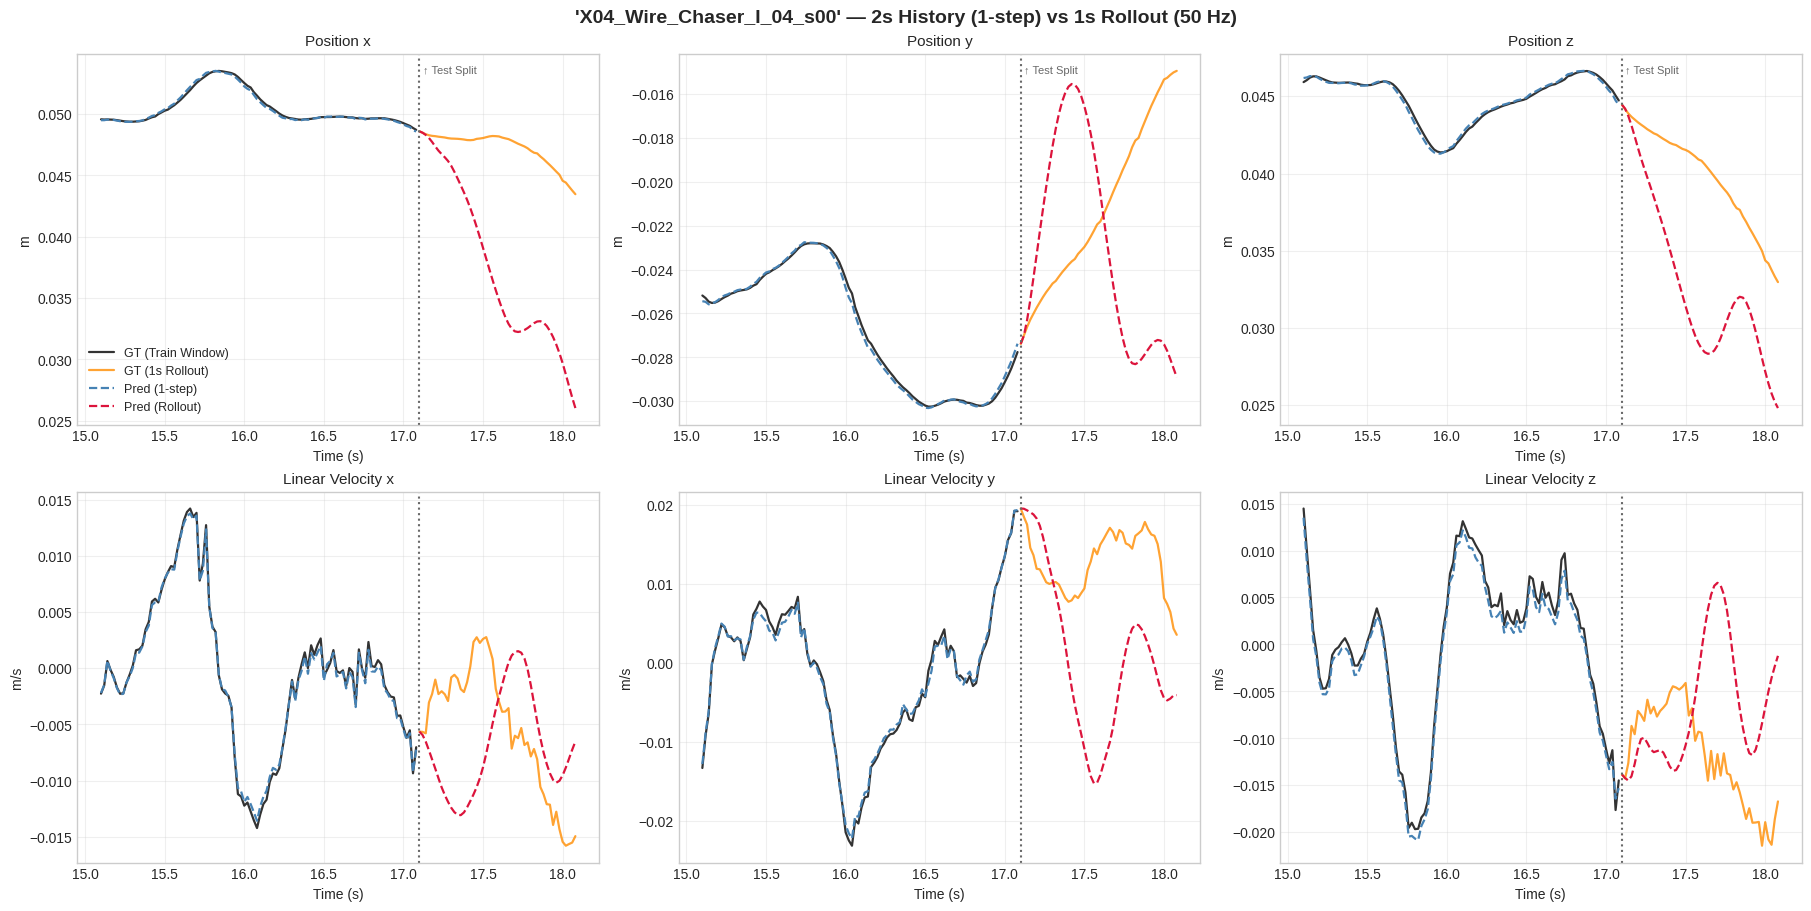

In [11]:
# ── Cell 11: Visualization & Analysis (ROSMA compatible) ───────────────────
from flax.core import unfreeze, freeze

# =============================================================================
# 0. FIX ROLLOUT FUNCTION (Shape Tracer Fix)
# =============================================================================
# Overriding the rollout from Cell 8 to explicitly initialize zero arrays
# instead of calling Flax module methods outside of an apply() context.
@partial(jax.jit, static_argnames=['model', 'n_steps'])
def _compiled_rollout_fixed(model, params, x0_batched, n_steps):
    batch_size = x0_batched.shape[0]

    # Explicit pure-JAX initialization of carry states to prevent shape tracer errors
    # h0 is a list of (c, h) tuples for each layer
    h0 = [(jnp.zeros((batch_size, model.hidden_size), dtype=jnp.float32),
           jnp.zeros((batch_size, model.hidden_size), dtype=jnp.float32))
          for _ in range(model.num_layers)]

    def step_fn(carry_and_state, _):
        carry, current_state = carry_and_state
        next_state, next_carry = model.apply(params, current_state, carry=carry, deterministic=True)
        return (next_carry, next_state), next_state

    _, trajectory = jax.lax.scan(step_fn, (h0, x0_batched), None, length=n_steps - 1)
    return jnp.concatenate([x0_batched[None, :], trajectory], axis=0)

def rollout_jax_fixed(wrapper, x0, n_steps):
    x0 = jnp.array(x0, dtype=jnp.float32)
    if x0.ndim == 1:
        x0 = x0[None, :]
    traj = _compiled_rollout_fixed(wrapper.model, wrapper.params, x0, n_steps)
    return np.array(traj[:, 0, :])

# =============================================================================
# FIX PARAMETER SCOPING FOR ROLLOUT
# =============================================================================
# Because LSTMPredictor was trained with `carry=None`, Flax instantiated dummy
# LSTMCells which shifted the internal parameter naming to LSTMCell_2 and _3.
# During rollout, `carry` is provided, shifting expected names back to _0 and _1.
params_unfrozen = unfreeze(final_params)
rollout_params_dict = {}
for k, v in params_unfrozen['params'].items():
    if k == 'LSTMCell_2':
        rollout_params_dict['LSTMCell_0'] = v
    elif k == 'LSTMCell_3':
        rollout_params_dict['LSTMCell_1'] = v
    else:
        rollout_params_dict[k] = v

rollout_params = freeze({'params': rollout_params_dict})
# Create a dedicated wrapper with the correctly mapped parameters for rollout
eval_model_rollout = EvalWrapper(dnn, rollout_params)

# =============================================================================
# 1. Select a reference trial (longest one from test_segs, or fallback)
# =============================================================================
# Look for a trial with many steps – prefer test_segs for rollout visualisation
candidate_list = test_segs if test_segs else ood_segs
ref_trial = max(candidate_list, key=lambda t: len(t['states']))
print(f"Visualising trial: {ref_trial['name']} ({len(ref_trial['states'])} frames)")

# =============================================================================
# 2. Prepare Data
# =============================================================================
states = np.array(ref_trial['states'])
T = len(states)
split_idx = int(T * 0.9)                  # Last 10% for rollout

# Number of steps for the two regimes (50 Hz → 0.02 s per step)
n_steps_plot_train = 100                  # 2 seconds of 1-step prediction history
n_steps_test = 50                         # Rollout exactly 1 second
t_boundary = split_idx * DT               # time at split

# Sub-select indices
tr_start = max(0, split_idx - n_steps_plot_train)
et_end = min(T, split_idx + n_steps_test)

# Time vectors
t_full = np.arange(T) * DT
t_tr = t_full[tr_start:split_idx]
t_et = t_full[split_idx:et_end]

# Ground truth
true_tr = states[tr_start:split_idx]
true_et = states[split_idx:et_end]

# -----------------------------------------------------------------------------
# FIX: Normalize, Predict, Unpack Tuple, Unnormalize, and use rollout_jax_fixed
# -----------------------------------------------------------------------------
# 1-step teacher-forced predictions (train window)
xt_tr_raw = states[tr_start : split_idx]                      # inputs: x[t] raw
xt_tr_norm = (xt_tr_raw - state_mean) / state_std             # scale to NN distribution
pred_tr_norm, _ = eval_model(xt_tr_norm)                      # UNPACK the (pred, carry) tuple
pred_tr = (np.asarray(pred_tr_norm) * state_std) + state_mean # scale back to physical units

# Rollout predictions (test window)
x0_test_raw = states[split_idx]                               # single starting frame
x0_test_norm = (x0_test_raw - state_mean) / state_std         # scale to NN distribution
pred_et_norm = rollout_jax_fixed(eval_model_rollout, x0_test_norm, n_steps_test) # Use FIXED rollout
pred_et = (np.asarray(pred_et_norm) * state_std) + state_mean # scale back to physical units

# =============================================================================
# 3. FIGURE 1: Trajectory Rollouts
# =============================================================================
labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]      # Position indices
linvel_idx = [6, 7, 8]     # Linear velocity indices

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
fig.suptitle(f"'{ref_trial['name']}' — 2s History (1-step) vs 1s Rollout (50 Hz)",
             fontsize=14, fontweight='bold')

C_GT_TR, C_GT_ET = 'black', 'darkorange'
C_PR_TR, C_PR_ET = 'steelblue', 'crimson'

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes[row, j]

        # Ground Truth
        ax.plot(t_tr, true_tr[:, idxs[j]], color=C_GT_TR, lw=1.6, alpha=0.80, label='GT (Train Window)')
        ax.plot(t_et, true_et[:, idxs[j]], color=C_GT_ET, lw=1.6, alpha=0.80, label='GT (1s Rollout)')

        # Predictions
        ax.plot(t_tr, pred_tr[:, idxs[j]], '--', color=C_PR_TR, lw=1.6, label='Pred (1-step)')
        ax.plot(t_et, pred_et[:, idxs[j]], '--', color=C_PR_ET, lw=1.6, label='Pred (Rollout)')

        # Train/Test boundary
        ax.axvline(x=t_boundary, color='dimgray', ls=':', lw=1.5)
        if row == 0:
            ax.text(t_boundary + 0.02, 0.97, '↑ Test Split', ha='left', va='top',
                    transform=ax.get_xaxis_transform(), fontsize=8, color='dimgray')

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

        if row == 0 and j == 0:
            ax.legend(loc='best', fontsize=9)

plt.show()

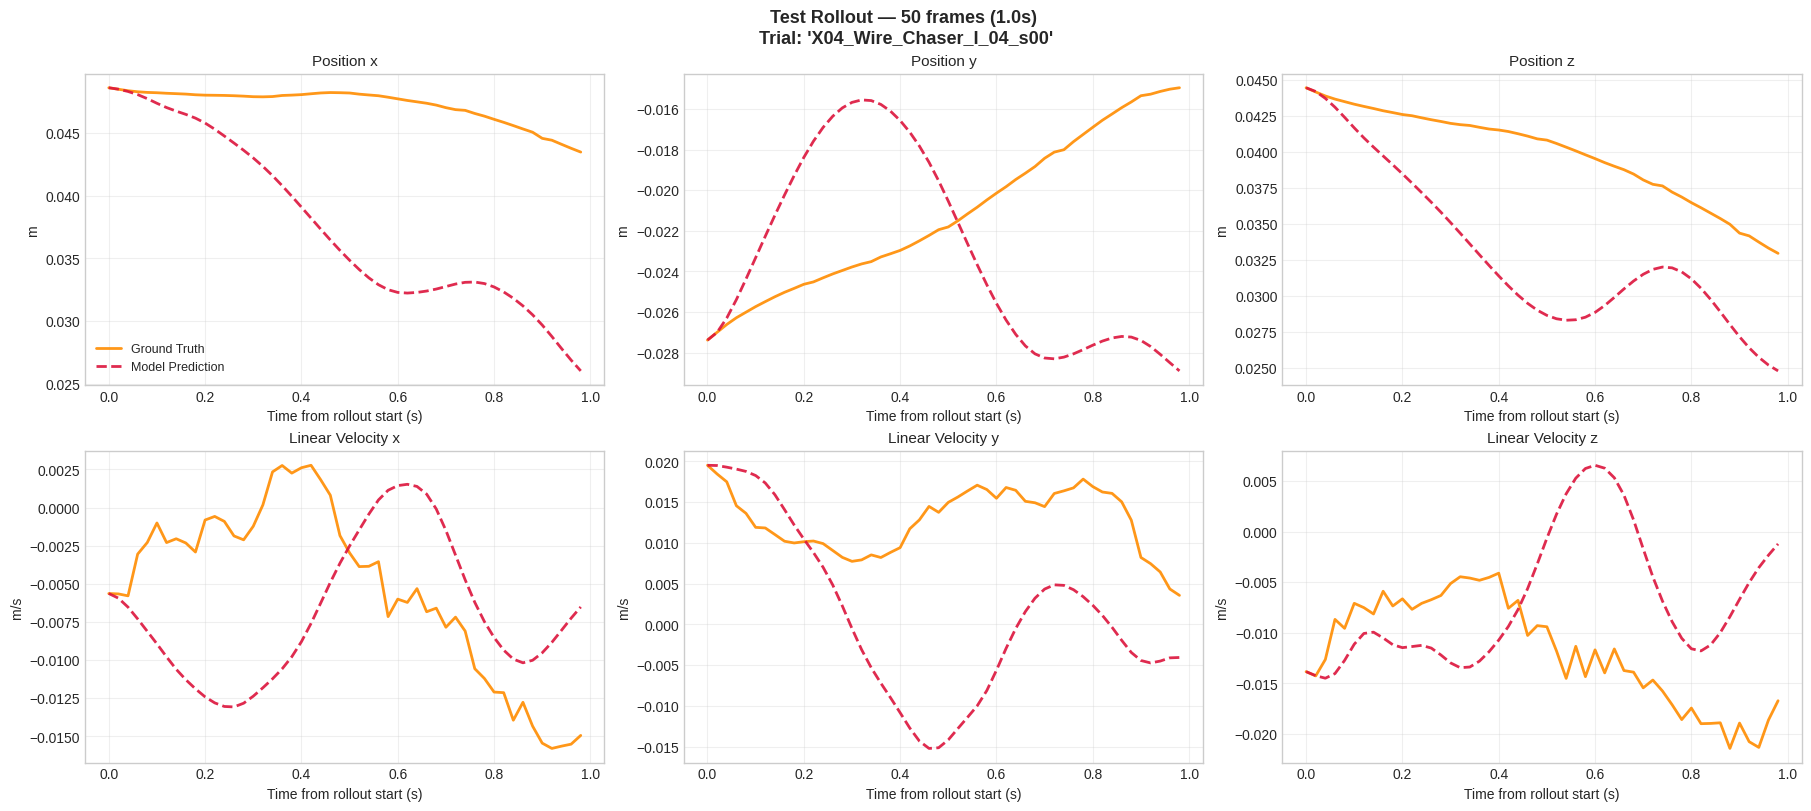

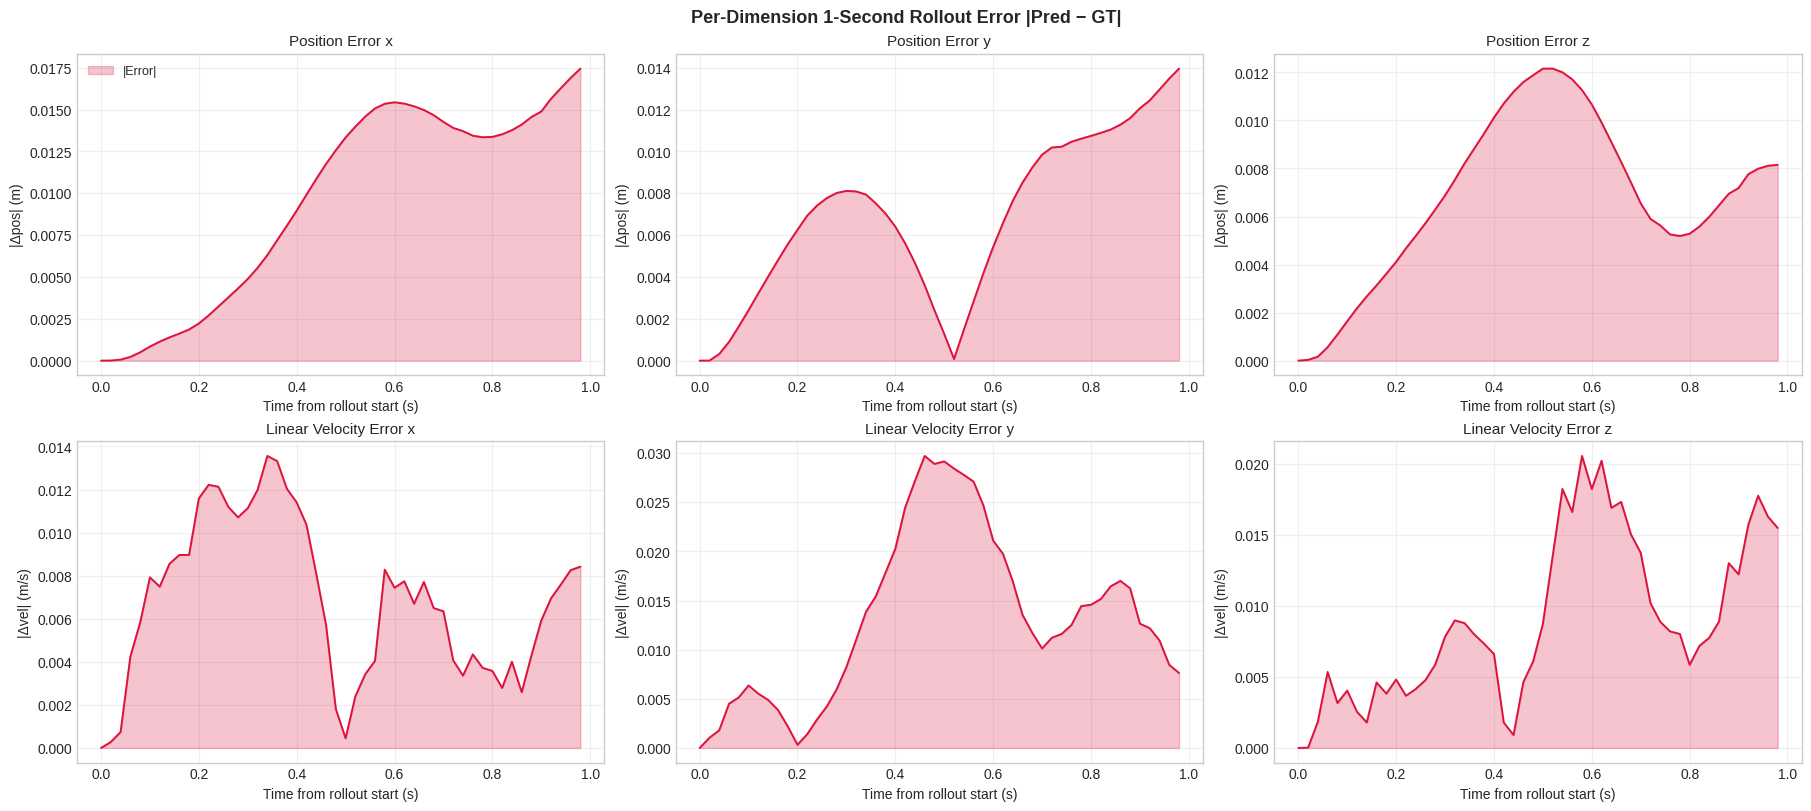

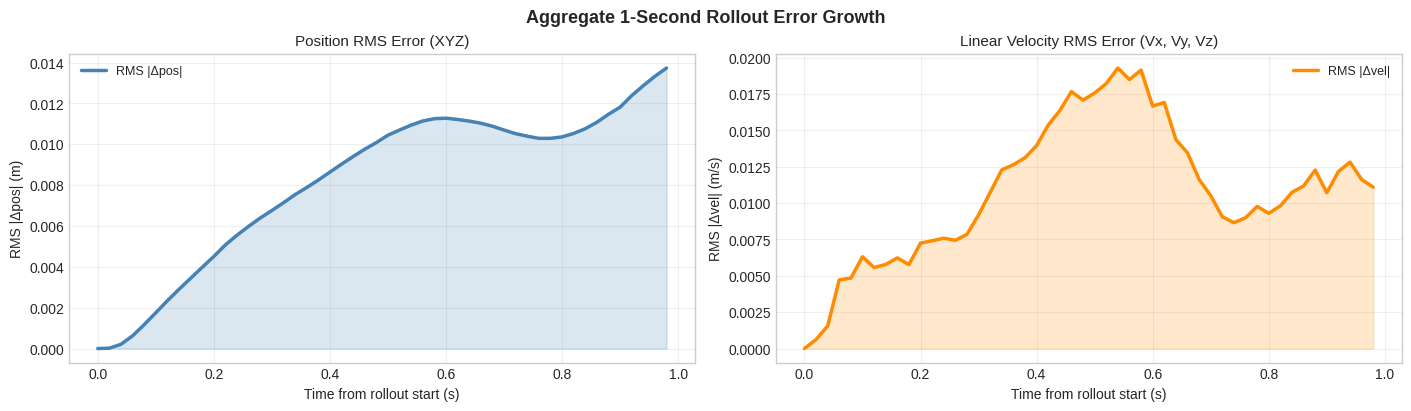

✓ Saved ID rollout trajectory: lstm_id_expert_trajectory_data.npz

1‑SECOND ROLLOUT ANALYSIS — 50 frames (1.00s)
Trial: 'X04_Wire_Chaser_I_04_s00'
----------------------------------------------------------------------
Position RMS Error (m):
  Initial : 2.150797e-09
  Final   : 1.373196e-02
  Peak    : 1.373196e-02  (at t=0.98s)
  Mean    : 8.178483e-03
----------------------------------------------------------------------
Velocity RMS Error (m/s):
  Initial : 0.000000e+00
  Final   : 1.109586e-02
  Peak    : 1.929175e-02  (at t=0.54s)
  Mean    : 1.083877e-02
----------------------------------------------------------------------

Per-Dimension Final Errors at t=0.98s:
  X: Δpos = 1.744673e-02 m  |  Δvel = 8.420022e-03 m/s
  Y: Δpos = 1.395868e-02 m  |  Δvel = 7.624368e-03 m/s
  Z: Δpos = 8.152720e-03 m  |  Δvel = 1.550246e-02 m/s

✓ Saved visualizations:
  1. glnn_rosma_test_traj.png
  2. glnn_rosma_test_error.png
  3. glnn_rosma_test_rms_error.png



In [12]:
# ── Cell 12: Rollout Error Analysis & Visualization (ROSMA) ─────────────────

# =============================================================================
# 1. Variable Alignment (from Cell 11)
# =============================================================================
T_total = len(states)
T_tr = split_idx
T_et = len(true_et)                     # 50 frames for a 1‑second rollout at 50 Hz

# Shift time so the test plot starts at t=0
t_test_relative = t_et - t_et[0]

labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]
linvel_idx = [6, 7, 8]

# Absolute error arrays directly from unscaled raw predictions
err_et = np.abs(pred_et - true_et)      # Shape: (50, 12)

# =============================================================================
# 2. FIGURE 3: Ground Truth vs Prediction (Test Window Only)
# =============================================================================
fig3, axes3 = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
fig3.suptitle(
    f"Test Rollout — {T_et} frames ({T_et*DT:.1f}s) \nTrial: '{ref_trial['name']}'",
    fontsize=13, fontweight='bold')

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes3[row, j]
        ax.plot(t_test_relative, true_et[:, idxs[j]], color='darkorange',
                lw=2.0, alpha=0.90, label='Ground Truth')
        ax.plot(t_test_relative, pred_et[:, idxs[j]], '--', color='crimson',
                lw=2.0, alpha=0.90, label='Model Prediction')

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time from rollout start (s)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0:
            ax.legend(fontsize=9)

plt.savefig('glnn_rosma_test_traj.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 3. FIGURE 4: Per-Dimension Absolute Error Over Time
# =============================================================================
fig4, axes4 = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
fig4.suptitle(
    f"Per-Dimension 1‑Second Rollout Error |Pred − GT|",
    fontsize=13, fontweight='bold')

ylabels2 = ['|Δpos| (m)', '|Δvel| (m/s)']
for row, idxs, ylbl, kind in [(0, trans_idx, ylabels2[0], 'Position Error'),
                              (1, linvel_idx, ylabels2[1], 'Linear Velocity Error')]:
    for j in range(3):
        ax = axes4[row, j]
        ax.fill_between(t_test_relative, 0, err_et[:, idxs[j]],
                        color='crimson', alpha=0.25, label='|Error|')
        ax.plot(t_test_relative, err_et[:, idxs[j]], color='crimson', lw=1.4)

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time from rollout start (s)')
        ax.set_ylabel(ylbl)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0:
            ax.legend(fontsize=9)

plt.savefig('glnn_rosma_test_error.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 4. FIGURE 5: Aggregate RMS Error Curves
# =============================================================================
pos_err_t = np.sqrt(np.mean(err_et[:, :3] ** 2, axis=1))
vel_err_t = np.sqrt(np.mean(err_et[:, 6:9] ** 2, axis=1))

fig5, ax5 = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
fig5.suptitle('Aggregate 1‑Second Rollout Error Growth', fontsize=13, fontweight='bold')

# Position error
ax5[0].plot(t_test_relative, pos_err_t, color='steelblue', lw=2.5, label='RMS |Δpos|')
ax5[0].fill_between(t_test_relative, 0, pos_err_t, alpha=0.2, color='steelblue')
ax5[0].set_title('Position RMS Error (XYZ)', fontsize=11)
ax5[0].set_xlabel('Time from rollout start (s)')
ax5[0].set_ylabel('RMS |Δpos| (m)')
ax5[0].grid(alpha=0.3)
ax5[0].legend(fontsize=9)

# Velocity error
ax5[1].plot(t_test_relative, vel_err_t, color='darkorange', lw=2.5, label='RMS |Δvel|')
ax5[1].fill_between(t_test_relative, 0, vel_err_t, alpha=0.2, color='darkorange')
ax5[1].set_title('Linear Velocity RMS Error (Vx, Vy, Vz)', fontsize=11)
ax5[1].set_xlabel('Time from rollout start (s)')
ax5[1].set_ylabel('RMS |Δvel| (m/s)')
ax5[1].grid(alpha=0.3)
ax5[1].legend(fontsize=9)

plt.savefig('glnn_rosma_test_rms_error.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 5. Save Full ID Rollout Trajectory
# =============================================================================

np.savez(
    'lstm_id_expert_trajectory_data.npz',
    time_one_step=t_tr,
    true_one_step=true_tr,
    pred_one_step=pred_tr,
    time_rollout=t_test_relative,
    true_rollout=true_et,
    pred_rollout=pred_et
)

print("✓ Saved ID rollout trajectory: lstm_id_expert_trajectory_data.npz")

# =============================================================================
# 6. Summary Statistics Terminal Output
# =============================================================================
W = 70
print(f"\n{'='*W}")
print(f"1‑SECOND ROLLOUT ANALYSIS — {T_et} frames ({T_et*DT:.2f}s)")
print(f"{'='*W}")
print(f"Trial: '{ref_trial['name']}'")
print(f"-" * W)
print(f"Position RMS Error (m):")
print(f"  Initial : {pos_err_t[0]:.6e}")
print(f"  Final   : {pos_err_t[-1]:.6e}")
print(f"  Peak    : {pos_err_t.max():.6e}  (at t={t_test_relative[pos_err_t.argmax()]:.2f}s)")
print(f"  Mean    : {pos_err_t.mean():.6e}")
print(f"-" * W)
print(f"Velocity RMS Error (m/s):")
print(f"  Initial : {vel_err_t[0]:.6e}")
print(f"  Final   : {vel_err_t[-1]:.6e}")
print(f"  Peak    : {vel_err_t.max():.6e}  (at t={t_test_relative[vel_err_t.argmax()]:.2f}s)")
print(f"  Mean    : {vel_err_t.mean():.6e}")
print(f"-" * W)

# Per-dimension analysis breakdown
print(f"\nPer-Dimension Final Errors at t={t_test_relative[-1]:.2f}s:")
for i, label in enumerate(labels):
    pos_err_final = err_et[-1, i]
    vel_err_final = err_et[-1, 6+i]
    print(f"  {label.upper()}: Δpos = {pos_err_final:.6e} m  |  Δvel = {vel_err_final:.6e} m/s")

print(f"\n✓ Saved visualizations:")
print(f"  1. glnn_rosma_test_traj.png")
print(f"  2. glnn_rosma_test_error.png")
print(f"  3. glnn_rosma_test_rms_error.png")
print(f"{'='*W}\n")

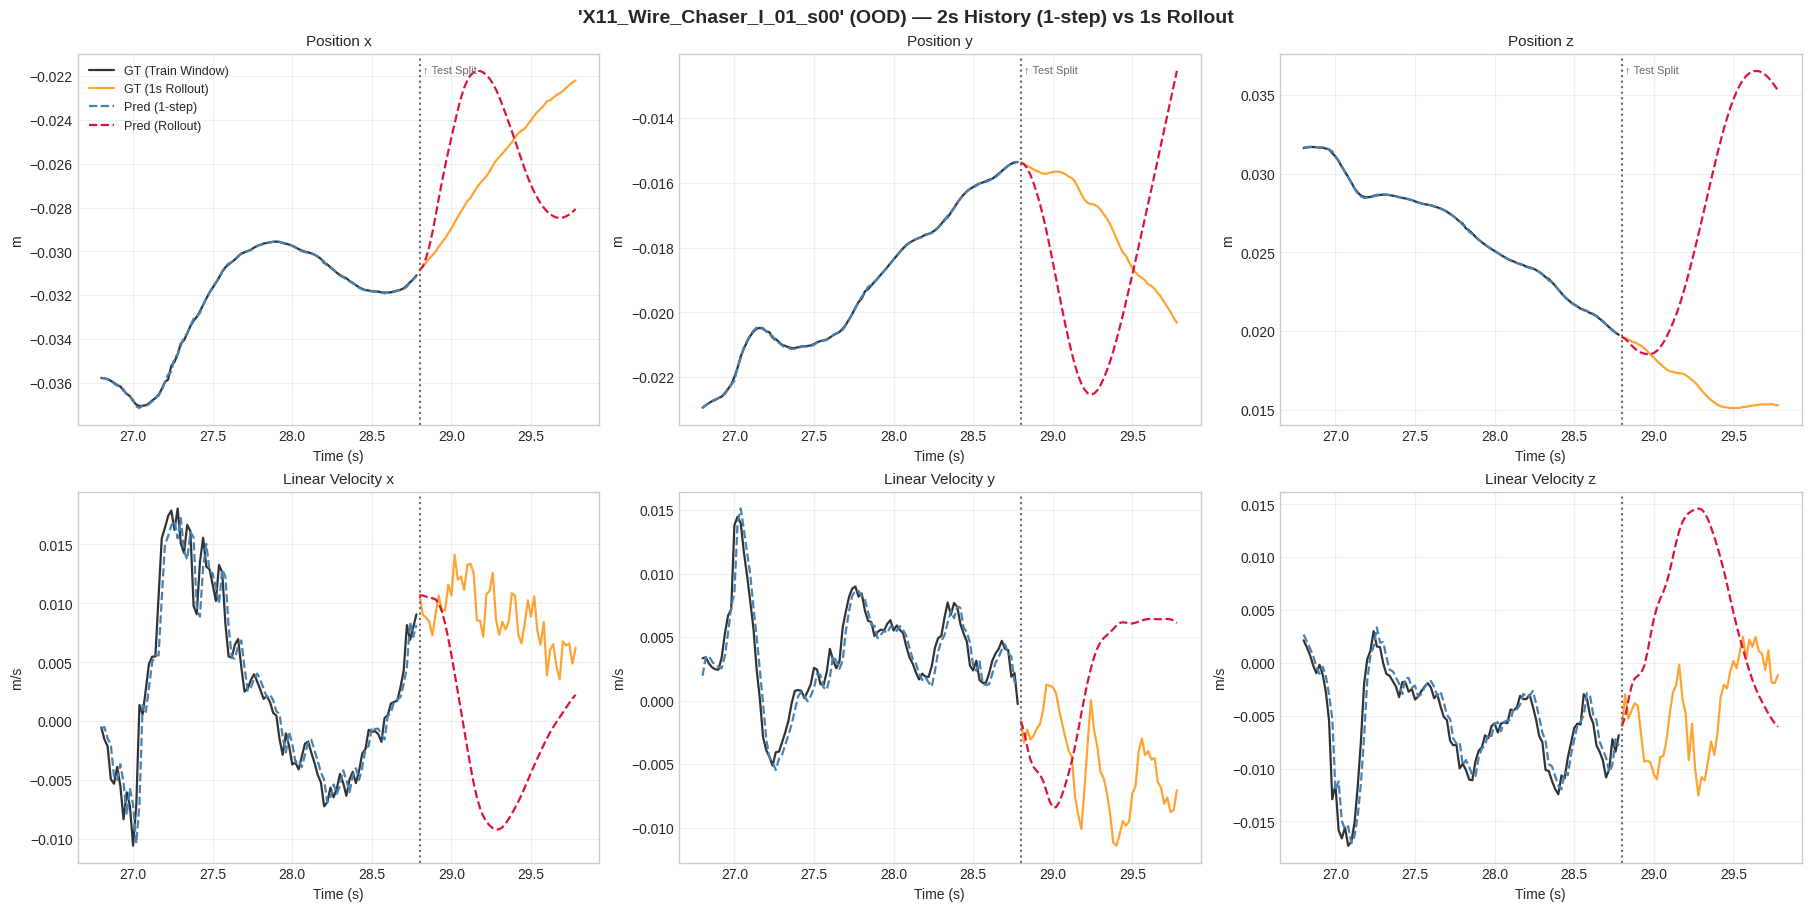

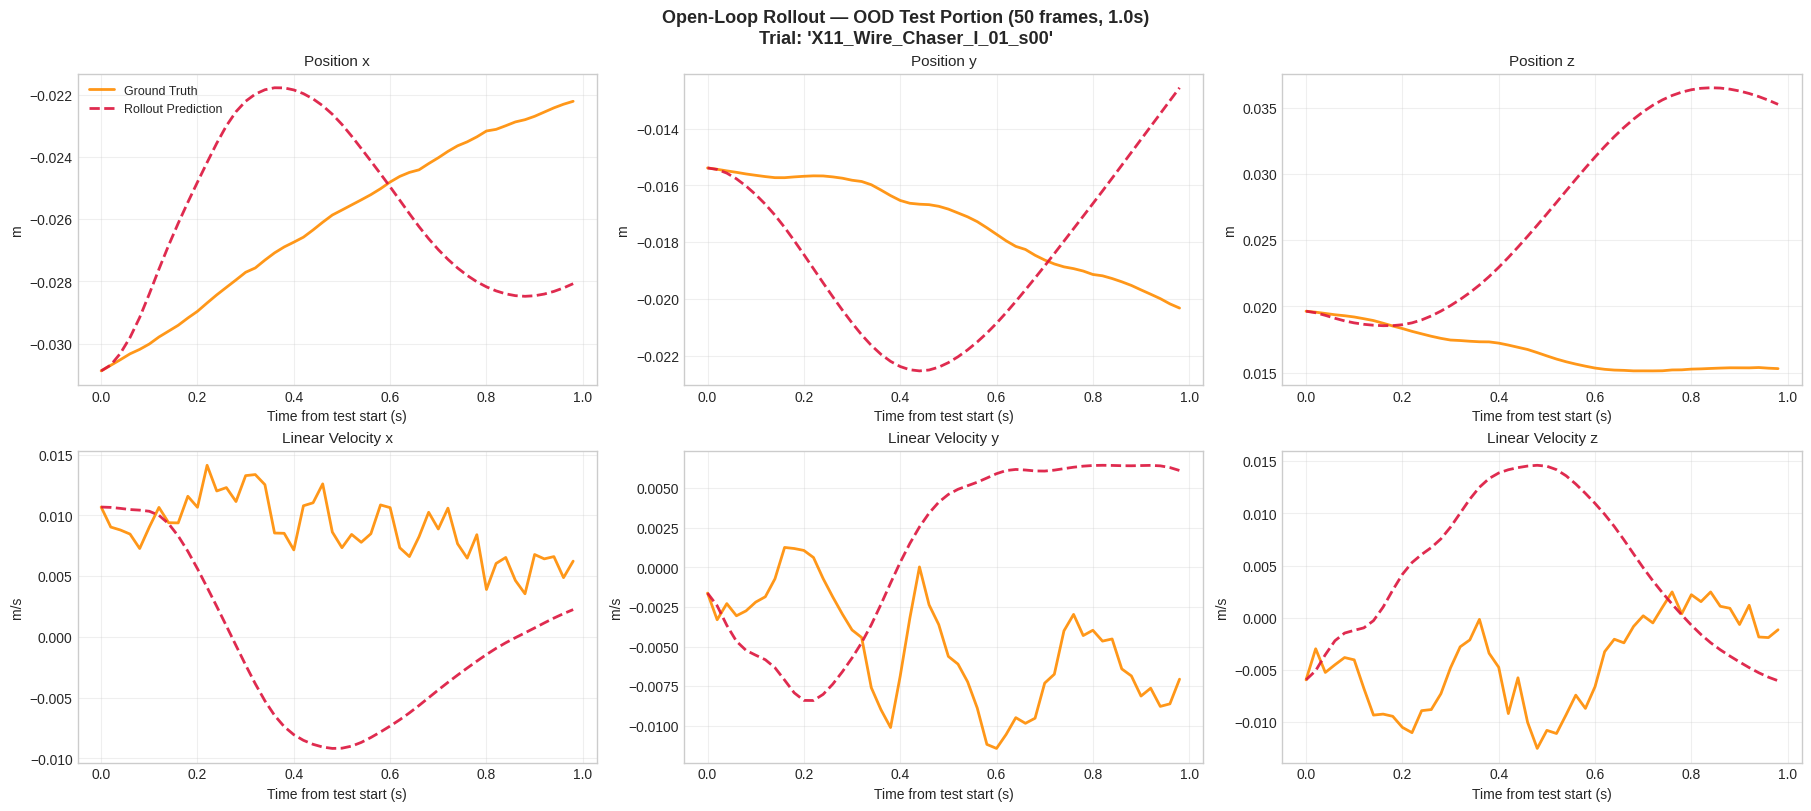

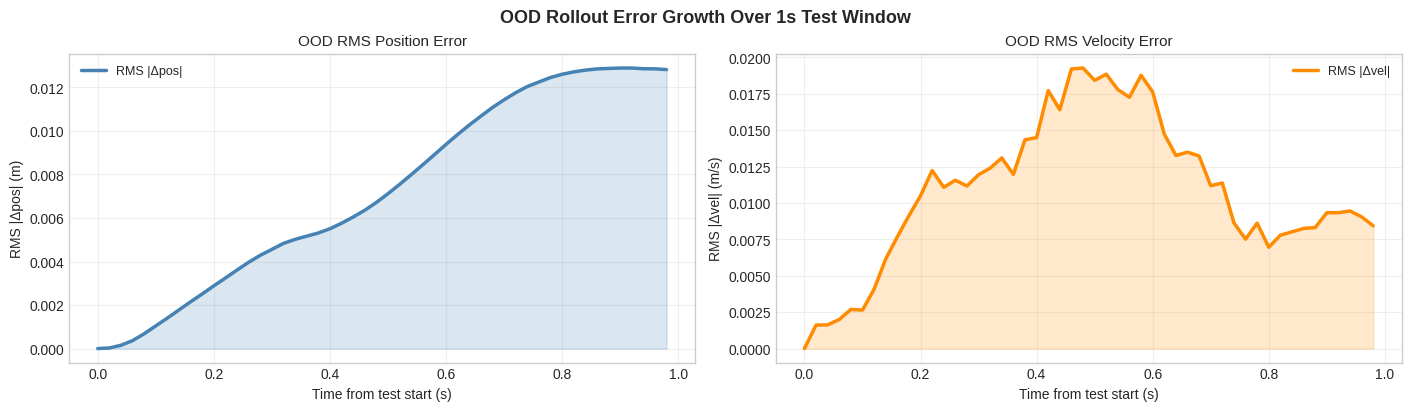

✓ Saved OOD rollout trajectory: lstm_ood_novice_trajectory_data.npz

OOD ROLLOUT ERROR ANALYSIS — 50 frames (1.00s)
Trial: X11_Wire_Chaser_I_01_s00
----------------------------------------------------------------------
Position RMS Error (m):
  Initial : 0.000000e+00
  Final   : 1.282019e-02
  Peak    : 1.289219e-02  (at t=0.92s)
  Mean    : 7.253419e-03
----------------------------------------------------------------------
Velocity RMS Error (m/s):
  Initial : 0.000000e+00
  Final   : 8.429785e-03
  Peak    : 1.926766e-02  (at t=0.48s)
  Mean    : 1.081169e-02
----------------------------------------------------------------------

TEST (ID) vs OOD GENERALIZATION GAP
Position Error Growth:
  Test (ID) final : 1.373196e-02 m
  OOD final       : 1.282019e-02 m
  Ratio (OOD/ID)  : 0.93×

Velocity Error Growth:
  Test (ID) final : 1.109586e-02 m/s
  OOD final       : 8.429785e-03 m/s
  Ratio (OOD/ID)  : 0.76×

✓ Saved OOD visualizations:
  1. glnn_ood_traj.png
  2. glnn_ood_test_traj.png
 

In [13]:
# ── Cell 13: OOD Trajectories & Error Analysis (ROSMA) ──────────────────────

# =============================================================================
# 1. Prepare Data: Generate OOD Predictions (RAW STATES)
# =============================================================================
# Select the longest OOD trial (X11/X12) for visualisation
ood_ref_trial = max(ood_segs, key=lambda t: len(t['states']))
ood_states = np.array(ood_ref_trial['states'])
ood_total = len(ood_states)
ood_tr_len = int(ood_total * 0.9)          # 90/10 split

# Rollout horizon: 1 second (50 frames at 50 Hz)
horizon_frames = min(ood_total - ood_tr_len, 50)
ood_t_boundary = ood_tr_len * DT

# Time vectors
ood_t_full = np.arange(ood_total) * DT
ood_t_tr = ood_t_full[:ood_tr_len]
ood_t_et = ood_t_full[ood_tr_len : ood_tr_len + horizon_frames]
ood_t_test_relative = ood_t_et - ood_t_et[0]   # Start at 0 for isolated plot

# Ground truth
ood_true_tr = ood_states[:ood_tr_len]
ood_true_et = ood_states[ood_tr_len : ood_tr_len + horizon_frames]

# -----------------------------------------------------------------------------
# FIX: Normalize, Predict, Unpack Tuple, Unnormalize, use rollout_jax_fixed
# -----------------------------------------------------------------------------
# 1-step teacher-forced predictions (OOD "train" portion)
ood_xt_tr_raw = ood_states[:ood_tr_len-1]
ood_xt_tr_norm = (ood_xt_tr_raw - state_mean) / state_std              # Normalization
ood_pred_tr_norm, _ = eval_model(ood_xt_tr_norm)                       # Unpack tuple
ood_pred_tr = (np.asarray(ood_pred_tr_norm) * state_std) + state_mean  # Unnormalization
ood_pred_tr = np.vstack([ood_states[0], ood_pred_tr])                  # Prepend initial state

# Rollout predictions (OOD test portion)
ood_x0_test_raw = ood_states[ood_tr_len]
ood_x0_test_norm = (ood_x0_test_raw - state_mean) / state_std          # Normalization

# Use FIXED rollout and explicitly mapped rollout model
ood_pred_et_norm = rollout_jax_fixed(eval_model_rollout, ood_x0_test_norm, horizon_frames)
ood_pred_et = (np.asarray(ood_pred_et_norm) * state_std) + state_mean  # Unnormalization

# Absolute errors
ood_err_et = np.abs(ood_pred_et - ood_true_et)

# Labels
labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]      # Position indices
linvel_idx = [6, 7, 8]     # Linear velocity indices

# =============================================================================
# 2. ZOOM LOGIC: Show only 2 seconds of Teacher-Forced data before the split
# =============================================================================
zoom_seconds = 2.0
zoom_frames = int(zoom_seconds / DT)    # 100 frames
zoom_start = max(0, ood_tr_len - zoom_frames)

ood_t_tr_zoom = ood_t_tr[zoom_start:]
ood_true_tr_zoom = ood_true_tr[zoom_start:]
ood_pred_tr_zoom = ood_pred_tr[zoom_start:]

# =============================================================================
# 3. FIGURE O1: OOD Train + Test on Same Axes (Zoomed)
# =============================================================================
fig_o1, axes_o1 = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
fig_o1.suptitle(f"'{ood_ref_trial['name']}' (OOD) — 2s History (1‑step) vs 1s Rollout",
                fontsize=14, fontweight='bold')

C_GT_TR, C_GT_ET = 'black', 'darkorange'
C_PR_TR, C_PR_ET = 'steelblue', 'crimson'

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes_o1[row, j]
        # Ground truth
        ax.plot(ood_t_tr_zoom, ood_true_tr_zoom[:, idxs[j]], color=C_GT_TR, lw=1.6, alpha=0.80,
                label='GT (Train Window)')
        ax.plot(ood_t_et, ood_true_et[:, idxs[j]], color=C_GT_ET, lw=1.6, alpha=0.80,
                label='GT (1s Rollout)')
        # Predictions
        ax.plot(ood_t_tr_zoom, ood_pred_tr_zoom[:, idxs[j]], '--', color=C_PR_TR, lw=1.6,
                label='Pred (1‑step)')
        ax.plot(ood_t_et, ood_pred_et[:, idxs[j]], '--', color=C_PR_ET, lw=1.6,
                label='Pred (Rollout)')

        ax.axvline(x=ood_t_boundary, color='dimgray', ls=':', lw=1.5)
        if row == 0:
            ax.text(ood_t_boundary + 0.02, 0.97, '↑ Test Split', ha='left', va='top',
                    transform=ax.get_xaxis_transform(), fontsize=8, color='dimgray')

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0:
            ax.legend(fontsize=9, loc='best')

plt.savefig('glnn_ood_traj.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 4. FIGURE O2: OOD Test Portion Only (Rollout)
# =============================================================================
fig_o2, axes_o2 = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
fig_o2.suptitle(
    f"Open‑Loop Rollout — OOD Test Portion ({horizon_frames} frames, {horizon_frames*DT:.1f}s)\n"
    f"Trial: '{ood_ref_trial['name']}'",
    fontsize=13, fontweight='bold')

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes_o2[row, j]
        ax.plot(ood_t_test_relative, ood_true_et[:, idxs[j]], color='darkorange',
                lw=2.0, alpha=0.90, label='Ground Truth')
        ax.plot(ood_t_test_relative, ood_pred_et[:, idxs[j]], '--', color='crimson',
                lw=2.0, alpha=0.90, label='Rollout Prediction')

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time from test start (s)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0:
            ax.legend(fontsize=9)

plt.savefig('glnn_ood_test_traj.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 5. FIGURE O3: Aggregate RMS Error Curves
# =============================================================================
# RMS over 3D dimensions
ood_pos_err_t = np.sqrt(np.mean(ood_err_et[:, :3] ** 2, axis=1))   # Position
ood_vel_err_t = np.sqrt(np.mean(ood_err_et[:, 6:9] ** 2, axis=1))  # Linear velocity

fig_o3, ax_o3 = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
fig_o3.suptitle('OOD Rollout Error Growth Over 1s Test Window', fontsize=13, fontweight='bold')

# Position error
ax_o3[0].plot(ood_t_test_relative, ood_pos_err_t, color='steelblue', lw=2.5, label='RMS |Δpos|')
ax_o3[0].fill_between(ood_t_test_relative, 0, ood_pos_err_t, alpha=0.2, color='steelblue')
ax_o3[0].set_title('OOD RMS Position Error', fontsize=11)
ax_o3[0].set_xlabel('Time from test start (s)')
ax_o3[0].set_ylabel('RMS |Δpos| (m)')
ax_o3[0].grid(alpha=0.3)
ax_o3[0].legend(fontsize=9)

# Velocity error
ax_o3[1].plot(ood_t_test_relative, ood_vel_err_t, color='darkorange', lw=2.5, label='RMS |Δvel|')
ax_o3[1].fill_between(ood_t_test_relative, 0, ood_vel_err_t, alpha=0.2, color='darkorange')
ax_o3[1].set_title('OOD RMS Velocity Error', fontsize=11)
ax_o3[1].set_xlabel('Time from test start (s)')
ax_o3[1].set_ylabel('RMS |Δvel| (m/s)')
ax_o3[1].grid(alpha=0.3)
ax_o3[1].legend(fontsize=9)

plt.savefig('glnn_ood_test_rms_error.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 6. Save Full OOD Rollout Trajectory
# =============================================================================

np.savez(
    'lstm_ood_novice_trajectory_data.npz',
    time_one_step=ood_t_tr,
    true_one_step=ood_true_tr,
    pred_one_step=ood_pred_tr,
    time_rollout=ood_t_test_relative,
    true_rollout=ood_true_et,
    pred_rollout=ood_pred_et
)

print("✓ Saved OOD rollout trajectory: lstm_ood_novice_trajectory_data.npz")

# =============================================================================
# 7. Summary Statistics Terminal Output
# =============================================================================
W = 70
print(f"\n{'='*W}")
print(f"OOD ROLLOUT ERROR ANALYSIS — {horizon_frames} frames ({horizon_frames*DT:.2f}s)")
print(f"{'='*W}")
print(f"Trial: {ood_ref_trial['name']}")
print(f"-" * W)
print(f"Position RMS Error (m):")
print(f"  Initial : {ood_pos_err_t[0]:.6e}")
print(f"  Final   : {ood_pos_err_t[-1]:.6e}")
print(f"  Peak    : {ood_pos_err_t.max():.6e}  (at t={ood_t_test_relative[ood_pos_err_t.argmax()]:.2f}s)")
print(f"  Mean    : {ood_pos_err_t.mean():.6e}")
print(f"-" * W)
print(f"Velocity RMS Error (m/s):")
print(f"  Initial : {ood_vel_err_t[0]:.6e}")
print(f"  Final   : {ood_vel_err_t[-1]:.6e}")
print(f"  Peak    : {ood_vel_err_t.max():.6e}  (at t={ood_t_test_relative[ood_vel_err_t.argmax()]:.2f}s)")
print(f"  Mean    : {ood_vel_err_t.mean():.6e}")
print(f"-" * W)

# Comparison: Test (ID) vs OOD (Generalization Gap)
try:
    print(f"\n{'='*W}")
    print(f"TEST (ID) vs OOD GENERALIZATION GAP")
    print(f"{'='*W}")
    print(f"Position Error Growth:")
    print(f"  Test (ID) final : {pos_err_t[-1]:.6e} m")
    print(f"  OOD final       : {ood_pos_err_t[-1]:.6e} m")
    print(f"  Ratio (OOD/ID)  : {ood_pos_err_t[-1] / max(pos_err_t[-1], 1e-10):.2f}×")
    print(f"\nVelocity Error Growth:")
    print(f"  Test (ID) final : {vel_err_t[-1]:.6e} m/s")
    print(f"  OOD final       : {ood_vel_err_t[-1]:.6e} m/s")
    print(f"  Ratio (OOD/ID)  : {ood_vel_err_t[-1] / max(vel_err_t[-1], 1e-10):.2f}×")
    print(f"{'='*W}")
except NameError:
    print("\n[!] Test error variables (pos_err_t) not found. Run Cell 12 first to see ID/OOD Comparison.")

print(f"\n✓ Saved OOD visualizations:")
print(f"  1. glnn_ood_traj.png")
print(f"  2. glnn_ood_test_traj.png")
print(f"  3. glnn_ood_test_rms_error.png")

In [14]:
# ── Cell 14: Compute Dataset-Wide 1-Second Rollout Errors (ROSMA) ────────────

def compute_dataset_rollout_error(eval_wrapper, trials, scale_array, horizon_frames=50, step_size=50):
    """
    Computes the Filtered Mean Squared rollout error across the specified dataset.
    Uses raw state inputs, ensuring mathematical stability.
    """
    all_window_errors = []

    for t in trials:
        raw_states = np.array(t['states'])
        T = len(raw_states)

        # Slide a window across the entire trial
        for start_idx in range(0, T - horizon_frames, step_size):
            x0_raw = raw_states[start_idx]
            true_traj = raw_states[start_idx : start_idx + horizon_frames]

            # -------------------------------------------------------------
            # FIX: Normalize, Predict using rollout_jax_fixed, Unnormalize
            # -------------------------------------------------------------
            # 1. Scale input to NN distribution
            x0_norm = (x0_raw - state_mean) / state_std

            # 2. Use the fixed rollout function that handles carry state scoping
            pred_traj_norm = np.asarray(rollout_jax_fixed(eval_wrapper, x0_norm, horizon_frames))

            # 3. Scale predictions back to physical hardware units
            pred_traj = (pred_traj_norm * state_std) + state_mean

            # Scaled MSE: err = ((pred - true) / scale)**2
            err = ((pred_traj - true_traj) / scale_array)**2
            window_mse = np.mean(err)

            # Clip exploding trajectories so they don't corrupt the entire array with NaNs/Infs
            if np.isnan(window_mse) or np.isinf(window_mse):
                window_mse = 1e6

            all_window_errors.append(float(window_mse))

    all_window_errors = np.array(all_window_errors)

    # Calculate raw means
    raw_mean = float(np.mean(all_window_errors))

    # Filter out the top 1% outliers (numerical explosions)
    threshold = np.percentile(all_window_errors, 99.0)
    filtered_errors = all_window_errors[all_window_errors <= threshold]
    filtered_mean = float(np.mean(filtered_errors))

    # Calculate Outliers Percentage (Windows with scaled MSE > 100.0)
    outlier_percent = float(np.sum(all_window_errors > 100.0) / len(all_window_errors) * 100)

    return raw_mean, filtered_mean, outlier_percent

print("\nComputing 1-second Rollout Errors across the entire dataset...")

# Ensure normalization stats are available (re-initialized from previous cells if needed)
if 'state_std' not in globals():
    state_mean = np.mean(x_tr, axis=0)
    state_std = np.std(x_tr, axis=0)
    state_std = np.where(state_std < 1e-8, 1.0, state_std)

# We use state_std as the physical scale for velocity/position units
scale_array = np.array(state_std, dtype=np.float32)

# -------------------------------------------------------------
# FIX: Execute using eval_model_rollout (the correctly scoped params)
# -------------------------------------------------------------
ro_tr_mean, ro_tr_filt, ro_tr_out = compute_dataset_rollout_error(eval_model_rollout, train_segs, scale_array)
ro_nt_mean, ro_nt_filt, ro_nt_out = compute_dataset_rollout_error(eval_model_rollout, test_segs, scale_array)
ro_et_mean, ro_et_filt, ro_et_out = compute_dataset_rollout_error(eval_model_rollout, ood_segs, scale_array)

W = 105
print(f'\n{"="*W}')
print(f'{"1-SECOND ROLLOUT SCALED MSE (Dataset-Wide) — ROSMA":^{W}}')
print(f'{"="*W}')
print(f'  Train (ID)                : Raw Mean {ro_tr_mean:.4e} | Filtered Mean {ro_tr_filt:.4e} | Outliers: {ro_tr_out:.2f}%')
print(f'  Test (ID)                 : Raw Mean {ro_nt_mean:.4e} | Filtered Mean {ro_nt_filt:.4e} | Outliers: {ro_nt_out:.2f}%')
print(f'  Test (OOD)                : Raw Mean {ro_et_mean:.4e} | Filtered Mean {ro_et_filt:.4e} | Outliers: {ro_et_out:.2f}%')
print(f'{"="*W}\n')


Computing 1-second Rollout Errors across the entire dataset...

                           1-SECOND ROLLOUT SCALED MSE (Dataset-Wide) — ROSMA                            
  Train (ID)                : Raw Mean 1.3024e+00 | Filtered Mean 1.2248e+00 | Outliers: 0.00%
  Test (ID)                 : Raw Mean 1.2047e+00 | Filtered Mean 1.1792e+00 | Outliers: 0.00%
  Test (OOD)                : Raw Mean 6.4569e-01 | Filtered Mean 5.9541e-01 | Outliers: 0.00%



In [15]:
# ── Cell 15: Final Summary Table (ROSMA) ─────────────────────────────────────

# Calculate generalization gap safely (OOD vs ID Train)
if mse_tr_filt > 0:
    gen_gap = ((mse_et_filt - mse_tr_filt) / mse_tr_filt) * 100.0
else:
    gen_gap = 0.0

W = 85
print(f'\n{"="*W}')
print(f'{"FINAL SUMMARY TABLE — GLNN on ROSMA":^{W}}')
print(f'{"="*W}')
print(f'  Data source   : REAL ROSMA (dVRK kinematics + Hardware Wrench Forces)')
print(f'  Paradigm      : Train on ID subjects (LOUO), Test on OOD subjects (X11, X12)')
print(f'  Architecture  : L-net + F-net (JAX/Flax Compiled + MASS)')
print(f'')
print(f'  One-step MSE – ID (Train)                  {mse_tr_filt:.6e}  (Outliers: {out_tr:.2f}%)')
print(f'  One-step MSE – ID (Test, In-Dist)          {mse_nt_filt:.6e}  (Outliers: {out_nt:.2f}%)')
print(f'  One-step MSE – OOD (Test)                  {mse_et_filt:.6e}  (Outliers: {out_et:.2f}%)')
print(f'  Generalization Gap (OOD vs ID Train)       {gen_gap:.2f} %')
print(f'')
print(f'  1-Second Rollout MSE – ID (Train)          {ro_tr_filt:.6e}  (Outliers: {ro_tr_out:.2f}%)')
print(f'  1-Second Rollout MSE – ID (Test)           {ro_nt_filt:.6e}  (Outliers: {ro_nt_out:.2f}%)')
print(f'  1-Second Rollout MSE – OOD (Test)          {ro_et_filt:.6e}  (Outliers: {ro_et_out:.2f}%)')
print(f'')
print(f'{"="*W}')
print(f'  Notes:')
print(f'   • Train on ID subjects (X01–X10) with LOUO split, test on OOD (X11, X12).')
print(f'   • Rollouts bounded to 1.0 second (50 frames) to prevent open-loop drift.')
print(f'   • Correlation (r) > 0.5 indicates successful physical force discovery.')
print(f'{"="*W}\n')


                         FINAL SUMMARY TABLE — GLNN on ROSMA                         
  Data source   : REAL ROSMA (dVRK kinematics + Hardware Wrench Forces)
  Paradigm      : Train on ID subjects (LOUO), Test on OOD subjects (X11, X12)
  Architecture  : L-net + F-net (JAX/Flax Compiled + MASS)

  One-step MSE – ID (Train)                  4.597334e+01  (Outliers: 97.16%)
  One-step MSE – ID (Test, In-Dist)          3.341251e+01  (Outliers: 95.98%)
  One-step MSE – OOD (Test)                  4.014858e+01  (Outliers: 93.00%)
  Generalization Gap (OOD vs ID Train)       -12.67 %

  1-Second Rollout MSE – ID (Train)          1.224762e+00  (Outliers: 0.00%)
  1-Second Rollout MSE – ID (Test)           1.179222e+00  (Outliers: 0.00%)
  1-Second Rollout MSE – OOD (Test)          5.954109e-01  (Outliers: 0.00%)

  Notes:
   • Train on ID subjects (X01–X10) with LOUO split, test on OOD (X11, X12).
   • Rollouts bounded to 1.0 second (50 frames) to prevent open-loop drift.
   • Correlation (r